In [6]:
# # Spam Email Classification using Machine Learning

# ## Objective
# Build a Machine Learning model that classifies SMS messages as **Spam** or **Ham (Not Spam)** using Natural Language Processing (NLP).

# ### Dataset
# SMS Spam Collection Dataset (Kaggle)

# ### Algorithm
# Multinomial Naive Bayes

# ### Libraries
# Pandas, NumPy, Matplotlib, Seaborn, WordCloud, Scikit-learn

In [7]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter

plt.style.use("ggplot")

%matplotlib inline

In [9]:
# Load Dataset
# Load Dataset

df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only first two useful columns

df = df.iloc[:, :2]

# Rename columns

df.columns = ["label", "message"]

# Show first rows

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Dataset Information
print("="*50)

print("Dataset Shape :", df.shape)

print("="*50)

print("\nColumns")

print(df.columns)

print("\nMissing Values")

print(df.isnull().sum())

print("\nDuplicate Rows")

print(df.duplicated().sum())

print("\nSpam / Ham Distribution")

print(df["label"].value_counts())

print("\nDataset Information\n")

df.info()

Dataset Shape : (5572, 2)

Columns
Index(['label', 'message'], dtype='object')

Missing Values
label      0
message    0
dtype: int64

Duplicate Rows
403

Spam / Ham Distribution
label
ham     4825
spam     747
Name: count, dtype: int64

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
# Data Cleaning
# Remove duplicate messages

df.drop_duplicates(inplace=True)

# Reset Index

df.reset_index(drop=True, inplace=True)

print("New Dataset Shape :", df.shape)

df.head()

New Dataset Shape : (5169, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# Feature Engineering
# Message Length

df["length"] = df["message"].apply(len)

# Word Count

df["word_count"] = df["message"].apply(
    lambda x: len(x.split())
)

df.head()

,label,message,length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


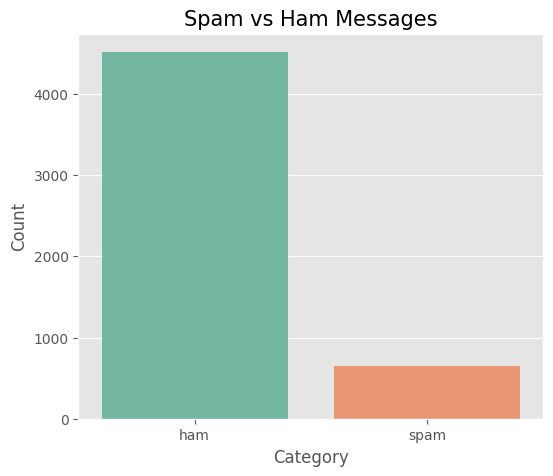

In [14]:
# Visualization 1 (Spam vs Ham)
plt.figure(figsize=(6,5))

sns.countplot(
    x="label",
    data=df,
    palette="Set2"
)

plt.title("Spam vs Ham Messages",fontsize=15)

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

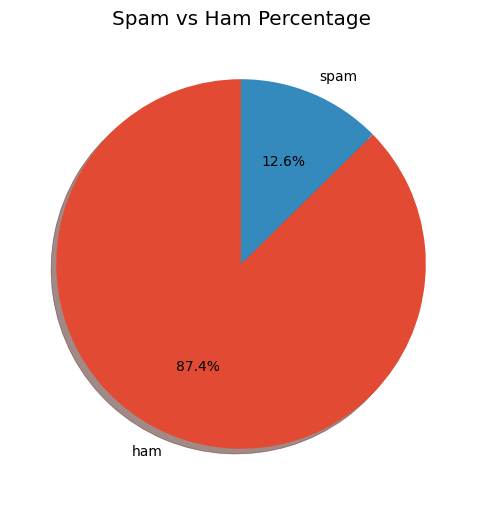

In [16]:
# Visualization 2 (Pie Chart)
plt.figure(figsize=(6,6))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.ylabel("")

plt.title("Spam vs Ham Percentage")

plt.show()

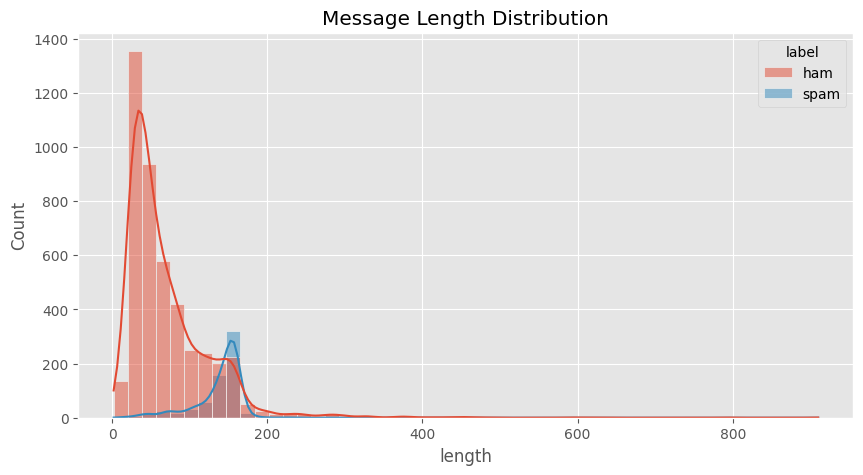

In [17]:
# Visualization 3 (Message Length Distribution)
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")

plt.show()

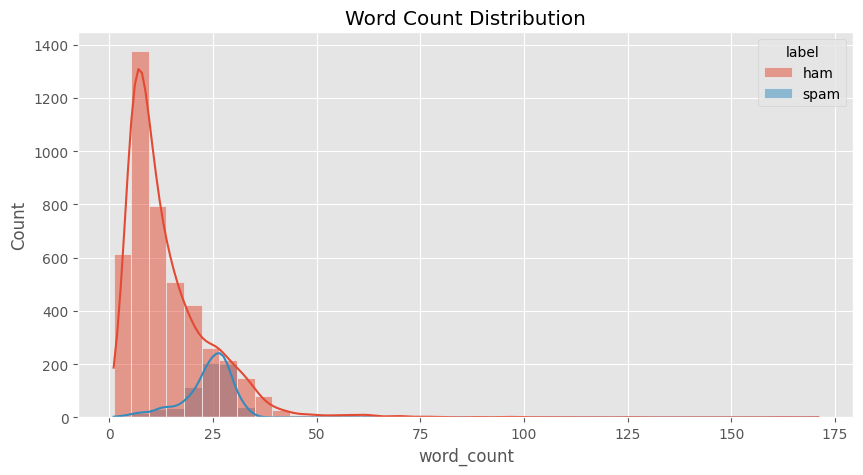

In [18]:
# Visualization 4 (Word Count Distribution)
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Word Count Distribution")

plt.show()

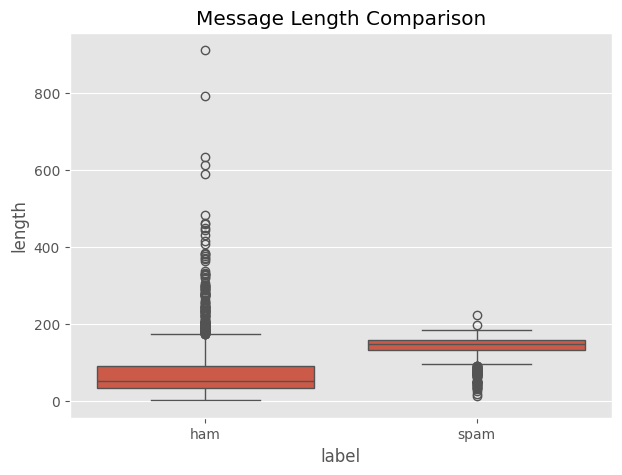

In [19]:
# Visualization 5 (Message Length Boxplot)
plt.figure(figsize=(7,5))

sns.boxplot(
    x="label",
    y="length",
    data=df
)

plt.title("Message Length Comparison")

plt.show()

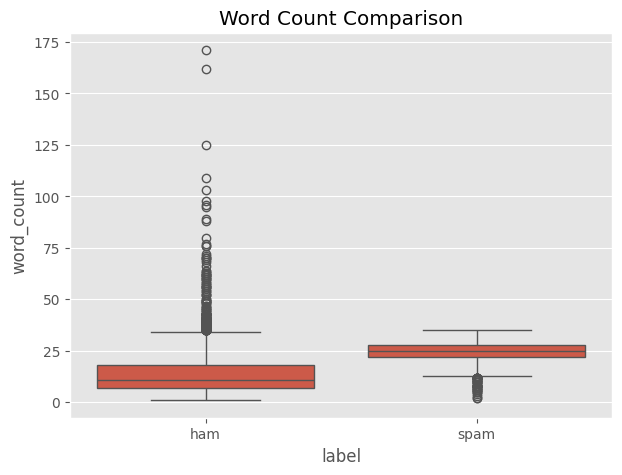

In [20]:
# Visualization 6 (Word Count Boxplot)
plt.figure(figsize=(7,5))

sns.boxplot(
    x="label",
    y="word_count",
    data=df
)

plt.title("Word Count Comparison")

plt.show()

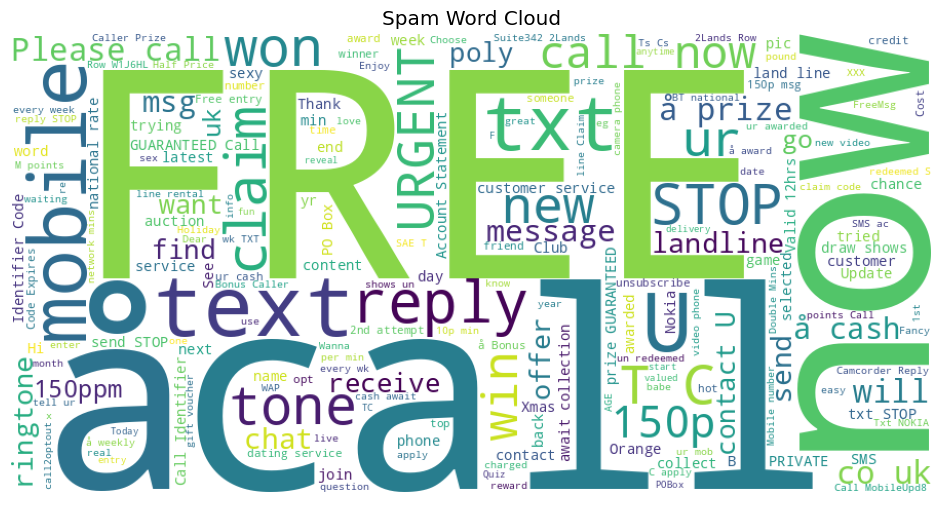

In [22]:
# Visualization 7 (Spam Word Cloud)
spam_words = " ".join(
    df[df["label"]=="spam"]["message"]
)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(spam_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam Word Cloud")

plt.show()

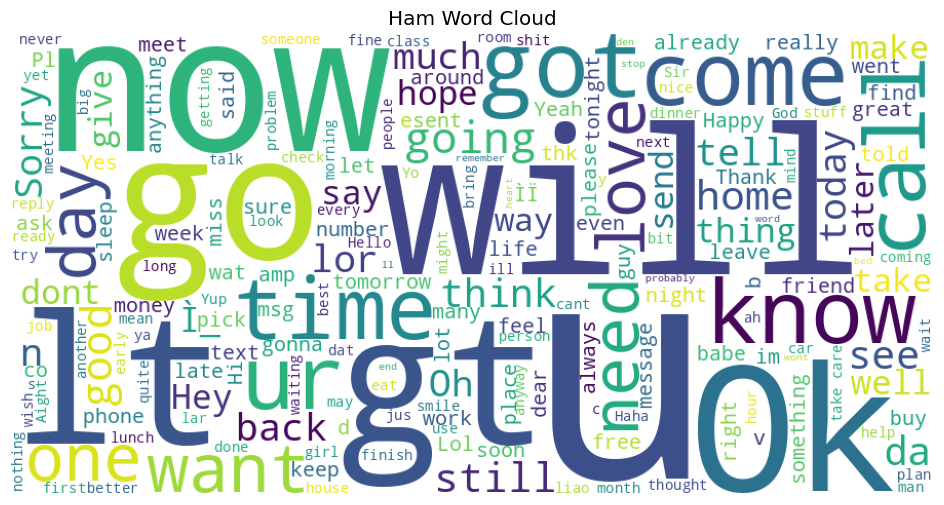

In [23]:
# Visualization 8 (Ham Word Cloud)
ham_words = " ".join(
    df[df["label"]=="ham"]["message"]
)

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(ham_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham Word Cloud")

plt.show()

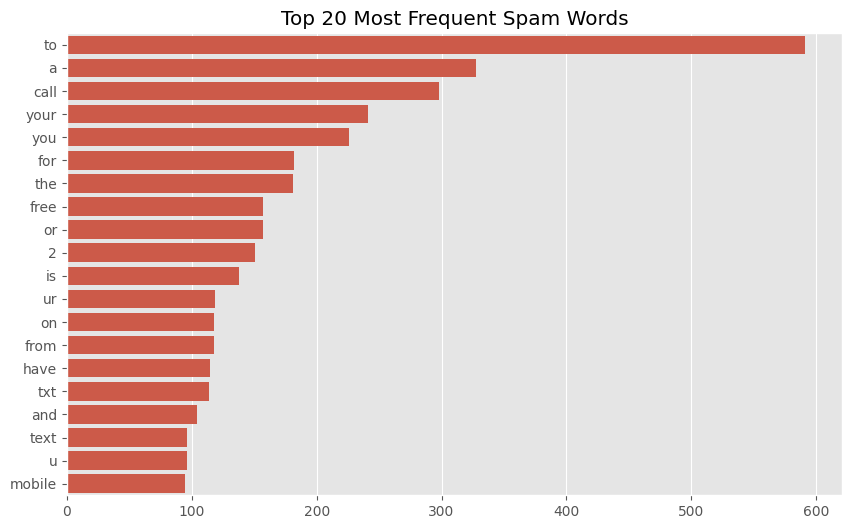

In [24]:
# Visualization 9 (Top 20 Spam Words)
spam = " ".join(
    df[df["label"]=="spam"]["message"]
).lower().split()

top_spam = Counter(spam).most_common(20)

words = [i[0] for i in top_spam]

counts = [i[1] for i in top_spam]

plt.figure(figsize=(10,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Spam Words")

plt.show()

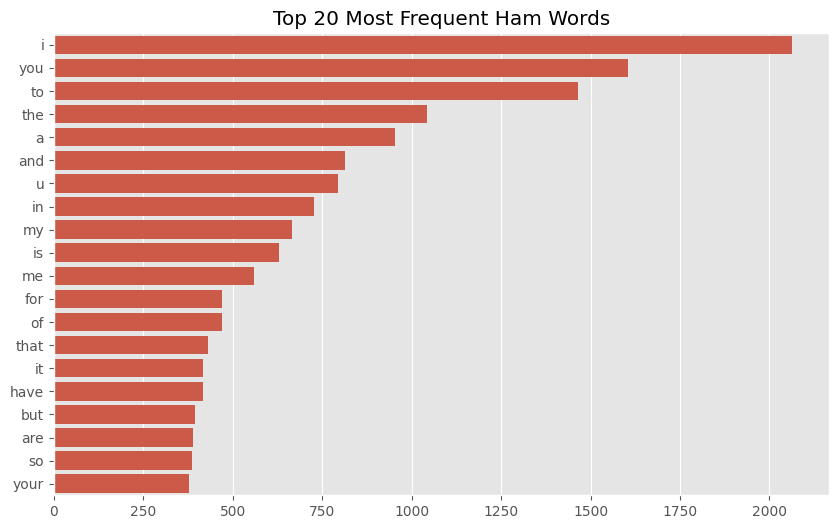

In [25]:
# Visualization 10 (Top 20 Ham Words)
ham = " ".join(
    df[df["label"]=="ham"]["message"]
).lower().split()

top_ham = Counter(ham).most_common(20)

words = [i[0] for i in top_ham]

counts = [i[1] for i in top_ham]

plt.figure(figsize=(10,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Ham Words")

plt.show()

In [26]:
# Encode Labels
# Convert labels to numeric values

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,length,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [27]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["message"]

y = df["label"]

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X = tfidf.fit_transform(X)

print("TF-IDF Shape :", X.shape)

TF-IDF Shape : (5169, 3000)


In [28]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (4135, 3000)
Testing Shape : (1034, 3000)


In [29]:
# Train Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [31]:
# Predictions
y_pred = model.predict(X_test)

In [32]:
# Model Performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

print("Accuracy :",round(accuracy*100,2),"%")

print("Precision :",round(precision*100,2),"%")

print("Recall :",round(recall*100,2),"%")

print("F1 Score :",round(f1*100,2),"%")

Accuracy : 97.78 %
Precision : 99.09 %
Recall : 83.21 %
F1 Score : 90.46 %


In [33]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.99      0.83      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



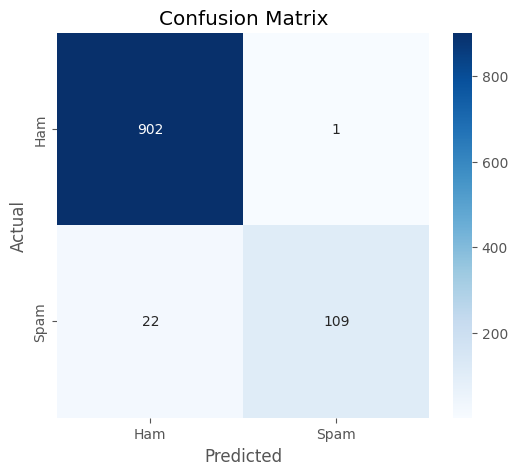

In [34]:
# Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

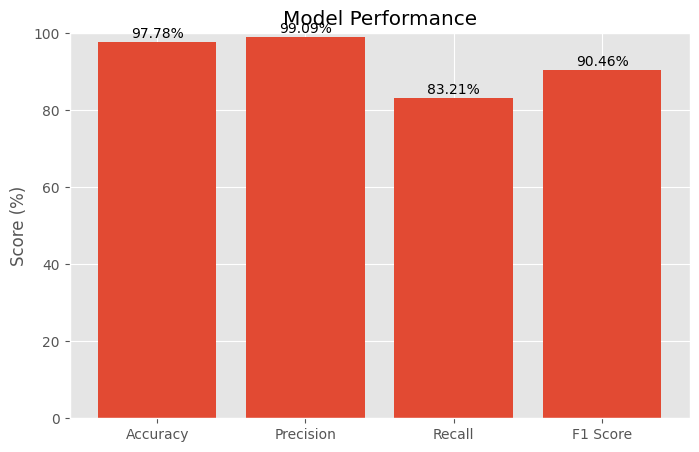

In [35]:
# Visualization: Model Performance Bar Chart
metrics = ["Accuracy","Precision","Recall","F1 Score"]

scores = [
    accuracy*100,
    precision*100,
    recall*100,
    f1*100
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    metrics,
    scores
)

plt.ylim(0,100)

plt.ylabel("Score (%)")

plt.title("Model Performance")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

plt.show()

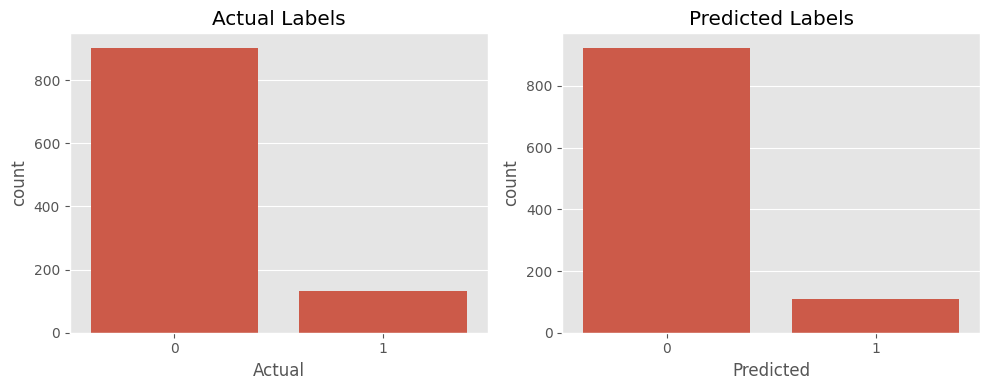

In [36]:
# Visualization: Actual vs Predicted Count
results = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

fig,ax = plt.subplots(1,2,figsize=(10,4))

sns.countplot(
    x="Actual",
    data=results,
    ax=ax[0]
)

ax[0].set_title("Actual Labels")

sns.countplot(
    x="Predicted",
    data=results,
    ax=ax[1]
)

ax[1].set_title("Predicted Labels")

plt.tight_layout()

plt.show()

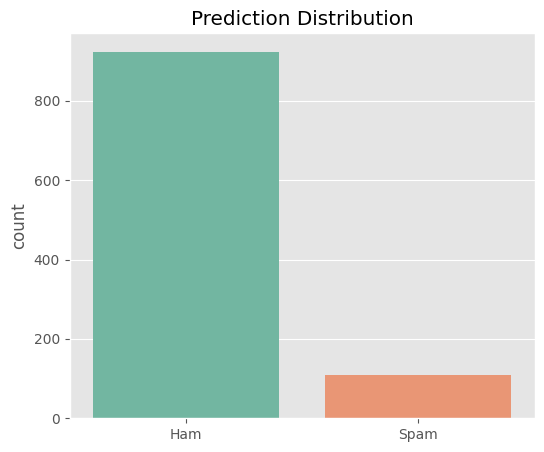

In [37]:
# Visualization: Prediction Distribution
plt.figure(figsize=(6,5))

sns.countplot(
    x=y_pred,
    palette="Set2"
)

plt.xticks(
    [0,1],
    ["Ham","Spam"]
)

plt.title("Prediction Distribution")

plt.show()

In [39]:
# Test Custom Messages
samples = [

    "Congratulations! You have won a FREE iPhone. Claim your prize now!",

    "Hi Rohan, let's meet tomorrow at 6 PM.",

    "URGENT! Your bank account has been suspended. Click here.",

    "Happy Birthday! Have a wonderful day."

]

sample_vector = tfidf.transform(samples)

predictions = model.predict(sample_vector)

for text,pred in zip(samples,predictions):

    print("="*80)

    print("Message :")

    print(text)

    print()

    if pred==1:
        print("Prediction : SPAM")

    else:
        print("Prediction : HAM")

Message :
Congratulations! You have won a FREE iPhone. Claim your prize now!

Prediction : SPAM
Message :
Hi Rohan, let's meet tomorrow at 6 PM.

Prediction : HAM
Message :
URGENT! Your bank account has been suspended. Click here.

Prediction : SPAM
Message :
Happy Birthday! Have a wonderful day.

Prediction : HAM


In [40]:
# Save Model
import joblib

joblib.dump(model,"spam_classifier.pkl")

joblib.dump(tfidf,"tfidf_vectorizer.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [41]:
# Final Conclusion
print("="*50)

print("PROJECT COMPLETED")

print("="*50)

print("Algorithm : Multinomial Naive Bayes")

print("Vectorizer : TF-IDF")

print(f"Accuracy : {accuracy*100:.2f}%")

print("Dataset : SMS Spam Collection")

print("Status : Ready for Deployment")

PROJECT COMPLETED
Algorithm : Multinomial Naive Bayes
Vectorizer : TF-IDF
Accuracy : 97.78%
Dataset : SMS Spam Collection
Status : Ready for Deployment
